In [20]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

from PIL import Image
import torch
import torch.nn as nn
import torchvision.transforms as T
from matplotlib import pyplot as plt, font_manager, rcParams

# Plot font configuration
FONT_PATH = "./fonts/nyk Ngayogyan Jejeg-Apri Nugroho-aksaradinusantara/nyk Ngayogyan Jejeg.ttf"
font_manager.fontManager.addfont(FONT_PATH)
rcParams["font.family"] = font_manager.FontProperties(fname=FONT_PATH).get_name()


In [21]:
NGLEGENA = [
    ("ꦲ","ha"), ("ꦤ","na"), ("ꦕ","ca"), ("ꦫ","ra"), ("ꦏ","ka"),
    ("ꦢ","da"), ("ꦠ","ta"), ("ꦱ","sa"), ("ꦮ","wa"), ("ꦭ","la"),
    ("ꦥ","pa"), ("ꦝ","dha"), ("ꦗ","ja"), ("ꦪ","ya"), ("ꦚ","nya"),
    ("ꦩ","ma"), ("ꦒ","ga"), ("ꦧ","ba"), ("ꦛ","tha"), ("ꦔ","nga"),
]

char_list = [c[0] for c in NGLEGENA]
char2idx = {c: i+1 for i, c in enumerate(char_list)}
idx2char = {i+1: c for i, c in enumerate(char_list)}
NUM_CLASSES = len(char_list) + 1


In [ ]:
class CRNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 64, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, 3, 1, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.Conv2d(256, 256, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d((2, 1)),

            nn.Conv2d(256, 512, 3, 1, 1),
            nn.BatchNorm2d(512),
            nn.ReLU(),

            nn.MaxPool2d((2, 1)),
            nn.AdaptiveAvgPool2d((1, None))
        )

        self.rnn = nn.LSTM(
            input_size=512, 
            hidden_size=256, 
            num_layers=2, 
            bidirectional=True, 
            batch_first=True
        )

        # BiLSTM output size is hidden_size * 2
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        # x shape: [batch, 1, 32, 128]
        x = self.cnn(x) 

        # After CNN & Adaptive Pool: [batch, 512, 1, width_reduced]
        x = x.squeeze(2)          # [batch, 512, width_reduced]
        x = x.permute(0, 2, 1)    # [batch, width_reduced, 512]

        # FIX: LSTM returns (output, hidden_state), we only need output
        x, _ = self.rnn(x)        # [batch, width_reduced, 512]

        x = self.fc(x)            # [batch, width_reduced, num_classes]
        return x



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.cuda.empty_cache()

model = CRNN(NUM_CLASSES).to(device)
model.load_state_dict(torch.load("./model/best_crnn_nglegena.pt", map_location=device, weights_only=False))
model.eval()


CRNN(
  (cnn): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=0,

In [23]:
def predict(img_path, model, idx2char):
    transform = T.Compose([
        T.Grayscale(1),
        T.Resize(48),
        T.ToTensor(),
        T.Normalize(mean=[0.5], std=[0.5])
    ])
    image = Image.open(img_path)
    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(image_tensor)

    preds = logits.argmax(2) # [batch, seq_len] (Greedy Search)
    pred = preds[0]

    decoded_text = []
    prev = 0
    for p in pred:
        p = p.item()
        if p != prev and p != 0: # 0 adalah index untuk blank token
            decoded_text.append(idx2char[p])
        prev = p
    
    result = "".join(decoded_text)

    plt.imshow(image, cmap='gray')
    plt.title(f"Prediction: {result}", fontsize=24)
    plt.axis('off')
    plt.show()

    return result


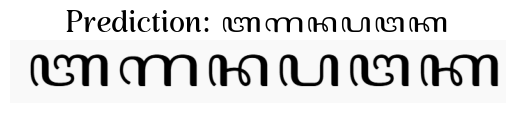

Hasil Prediksi: ꦧꦒꦤꦥꦔꦏ


In [72]:
prediction = predict("image-18.png", model, idx2char)
print(f"Hasil Prediksi: {prediction}")